# 기본 EDA — SHREC'17 손 제스처 데이터셋

**전처리를 설계하기 전에, 데이터 자체를 파악하는 단계**

## 이 노트북의 원칙

EDA에서 가장 흔한 함정은 아무도 사용하지 않는 그래프를 잔뜩 만드는 것이다.
이를 막는 규칙은 하나다 — **어떤 확인을 하기 전에, 그 결과가 바꿀 결정을 먼저 적는다.**
어떤 측정이 이후의 선택을 바꾸지 못한다면 그 측정은 생략한다.

아래 모든 항목에는 *그 결과가 어떤 결정에 쓰이는지*가 함께 적혀 있다.

## 구성

| 단계 | 질문 | 목적 |
|---|---|---|
| **Tier 1** | 데이터가 스스로의 규약을 지키는가? | 무결성. 여기서 실패하면 이후 분석이 전부 무의미 |
| **Tier 2** | 무엇이 얼마나 들어 있는가? | 구성과 균형 |
| **Tier 3** | 신호는 어떻게 생겼는가? | 움직임의 성질, 노이즈 수준 |
| **Tier 4** | 이 실험이 가능한가? | 프로젝트 고유의 타당성 |

## 프로젝트 배경

가림(occlusion) 구간에서 손 랜드마크를 복원할 때 **물리 기반**(등속·등가속도·칼만)과
**학습 기반**(LSTM·GRU·Transformer) 방법을 **가림 길이 L**에 따라 비교하고,
두 오차 곡선이 교차하는 지점을 찾는 것이 목표다.

## 0. 설정 및 원본 데이터 로드

이 노트북은 **전처리 이전** 단계이므로, 캐시(`cache/sequences.npz`)가 아니라 **원본 텍스트 파일**을
직접 읽는다. 캐시는 전처리의 산출물이므로 여기서 쓰면 검증의 의미가 없어진다.

`shrec.index`와 `shrec.load`는 파일을 파싱만 하는 얇은 리더이므로 사용해도 무방하다.

In [1]:
from pathlib import Path
import sys
import time

root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
sys.path.insert(0, str(root / "src"))

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 그래프에 한글 라벨을 쓰려면 한글 폰트를 지정해야 한다.
# 지정하지 않으면 DejaVu Sans가 쓰이는데 한글 글리프가 없어 네모(tofu)로 나온다.
import matplotlib.font_manager as fm
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ("Malgun Gothic", "NanumGothic", "Gulim"):
    if _f in _avail:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트에서 음수 기호 깨짐 방지
print("matplotlib 폰트:", plt.rcParams["font.family"])

from shrec import constants as C
from shrec.index import load_index
from shrec.load import load_world_skeleton

print("project root:", root)
print("data root   :", C.DATA_ROOT)
print("존재 여부   :", C.DATA_ROOT.exists())

matplotlib 폰트: ['Malgun Gothic']
project root: C:\Users\jimin\Desktop\1_KUBIG\Project
data root   : C:\Users\jimin\Desktop\1_KUBIG\Project\data\extracted\HandGestureDataset_SHREC2017
존재 여부   : True


원본 시퀀스 2800개를 한 번만 메모리에 올린다(약 1분). 이후 모든 분석은 이 리스트를 재사용한다.

**중요:** 이 노트북의 모든 통계는 무작위 표본이 아니라 **전체 데이터**로 계산한다.
그래야 재실행해도 같은 숫자가 나오고, 아래 "발견"에 적힌 값을 그대로 인용할 수 있다.

In [2]:
records = load_index()

t0 = time.perf_counter()
sequences = []
for n, rec in enumerate(records, 1):
    sequences.append(load_world_skeleton(rec))
    if n % 700 == 0:
        print(f"  loaded {n}/{len(records)}")
print(f"완료: {len(sequences)}개 시퀀스, {time.perf_counter() - t0:.0f}초")

total_frames = sum(len(s) for s in sequences)
print(f"총 프레임 수: {total_frames:,}")

  loaded 700/2800


  loaded 1400/2800


  loaded 2100/2800


  loaded 2800/2800
완료: 2800개 시퀀스, 3초
총 프레임 수: 164,969


---
# Tier 1 — 무결성 (Integrity)

> 데이터가 스스로 선언한 규약을 지키는가?

여기서 문제가 발견되면 이후 분석은 전부 무의미하므로 가장 먼저 수행한다.

## 1.1 디렉터리 구조와 파일 개수

**이 확인이 바꾸는 결정:** 압축 해제가 완전했는지, 추가 다운로드가 필요한지.

SHREC'17은 4중 요인 설계다.

```
gesture_{1..14} / finger_{1,2} / subject_{1..28} / essai_{1..5} /
      skeletons_world.txt       3D 월드 좌표
      skeletons_image.txt       2D 픽셀 좌표 + depth
      general_informations.txt  timestamp + 손 bounding box
      {0..T-1}_depth.png        640x480 16-bit depth map
```

In [3]:
sample_dir = records[0].dir_path
print(f"예시 디렉터리: {sample_dir.relative_to(C.DATA_ROOT)}")
for f in sorted(sample_dir.iterdir())[:4]:
    print(f"   {f.name:28} {f.stat().st_size:>10,} bytes")
print(f"   ... (depth PNG 총 {len(list(sample_dir.glob('*_depth.png')))}장)")

n_world = sum(1 for r in records if r.world_path.exists())
n_image = sum(1 for r in records if r.image_path.exists())
n_info = sum(1 for r in records if (r.dir_path / "general_informations.txt").exists())

print()
print(f"split 파일이 선언한 시퀀스 수   {len(records)}")
print(f"skeletons_world.txt 존재        {n_world}")
print(f"skeletons_image.txt 존재        {n_image}")
print(f"general_informations.txt 존재   {n_info}")

예시 디렉터리: gesture_1\finger_1\subject_2\essai_1
   0_depth.png                      93,566 bytes
   10_depth.png                    106,197 bytes
   11_depth.png                    112,150 bytes
   12_depth.png                     64,517 bytes
   ... (depth PNG 총 77장)



split 파일이 선언한 시퀀스 수   2800
skeletons_world.txt 존재        2800
skeletons_image.txt 존재        2800
general_informations.txt 존재   2800


설계가 완전교차(fully crossed)인지도 확인한다. "14 × 2 × 피험자 × 반복"이 딱 떨어지는지
직접 세어 보면, 이름만 보고 추측하는 것과 실제가 다를 수 있다.

In [4]:
n_subj = len({r.subject for r in records})
per_subject = Counter(r.subject for r in records)
essai_per_cell = Counter()
for r in records:
    essai_per_cell[(r.gesture, r.finger, r.subject)] += 1

print(f"고유 피험자 수            {n_subj}명")
print(f"피험자당 시퀀스 수        최소 {min(per_subject.values())} ~ 최대 {max(per_subject.values())}")
print(f"(제스처,손가락,피험자) 셀 {len(essai_per_cell)}개")
print(f"셀당 반복(essai) 수 분포  {dict(sorted(Counter(essai_per_cell.values()).items()))}")
print(f"\n완전교차라면 14 x 2 x {n_subj} x 5 = {14*2*n_subj*5} 이어야 하지만 실제는 {len(records)}")

고유 피험자 수            28명
피험자당 시퀀스 수        최소 20 ~ 최대 140
(제스처,손가락,피험자) 셀 745개
셀당 반복(essai) 수 분포  {1: 62, 2: 113, 3: 118, 4: 154, 5: 275, 6: 13, 7: 2, 8: 3, 9: 2, 10: 2, 13: 1}

완전교차라면 14 x 2 x 28 x 5 = 3920 이어야 하지만 실제는 2800


### 발견

* split 파일이 선언한 **2800개** 시퀀스가 모두 디스크에 존재한다. 누락 없음.
* 세 종류의 텍스트 파일이 모든 시퀀스에 대해 빠짐없이 존재한다.
* **설계는 완전교차가 아니다.** 고유 피험자는 **28명**이지만
  14 × 2 × 28 × 5 = 3920 ≠ 2800이다.
  즉 모든 피험자가 모든 제스처를 5번씩 수행한 것이 아니며,
  피험자마다 시퀀스 수가 다르고 반복 횟수도 셀마다 균일하지 않다.
* 그럼에도 **제스처 클래스별 개수는 정확히 균형**을 이룬다(2.2절에서 확인).
  즉 균형은 *피험자 축*이 아니라 *클래스 축*에서만 성립한다.
* `finger_1`은 **손가락 하나**, `finger_2`는 **손 전체**로 수행한 경우이며,
  이 구분 때문에 14 클래스가 28 클래스로 확장된다.

## 1.2 열(column) 개수 일관성

**이 확인이 바꾸는 결정:** `reshape(T, 22, 3)`을 무조건 적용해도 되는가, 파일마다 예외 처리가 필요한가.

파일 하나만 열어보고 판단하면 안 된다. 전체를 확인한다.

In [5]:
world_shapes = Counter(s.shape[1:] for s in sequences)
print("skeletons_world.txt 형태 분포:")
for shape, n in world_shapes.items():
    print(f"   {shape} -> {n}개 시퀀스")

# image 파일도 확인 (2D 이므로 44열이어야 함)
img_cols = Counter()
for rec in records[::20]:            # 140개 표본이면 충분히 대표적
    img_cols[np.loadtxt(rec.image_path, ndmin=2).shape[1]] += 1
print(f"\nskeletons_image.txt 열 개수 분포(표본 {sum(img_cols.values())}개): {dict(img_cols)}")

skeletons_world.txt 형태 분포:
   (22, 3) -> 2800개 시퀀스

skeletons_image.txt 열 개수 분포(표본 140개): {44: 140}


### 발견

* `skeletons_world.txt`는 **2800개 전부** `(T, 22, 3)` 형태다 → 22관절 × 3차원 = 66열.
  예외 처리 없이 일괄 `reshape` 가능.
* `skeletons_image.txt`는 44열 = 22관절 × 2차원(픽셀 x, y).
* **결론:** 월드 좌표(3D)와 이미지 좌표(2D)는 서로 다른 파일이다.
  궤적 예측 모델은 `skeletons_world.txt`를 쓰고, `skeletons_image.txt`는
  depth 영상 위에 오버레이할 때만 필요하다.

## 1.3 프레임 수 일치

**이 확인이 바꾸는 결정:** split 파일의 프레임 수를 신뢰할 수 있는가, PNG 인덱스와 스켈레톤 행이
1:1로 대응하는가 (오버레이 데모의 전제).

네 가지 출처의 프레임 수가 모두 일치해야 한다:
split 파일 선언값 · `skeletons_world.txt` 행 수 · `skeletons_image.txt` 행 수 · depth PNG 장수.

In [6]:
mismatch_world, mismatch_image = [], []
for rec, seq in zip(records, sequences):
    if len(seq) != rec.n_frames:
        mismatch_world.append(rec.seq_id)

for rec in records[::20]:
    if np.loadtxt(rec.image_path, ndmin=2).shape[0] != rec.n_frames:
        mismatch_image.append(rec.seq_id)

print(f"world 행 수 != split 선언값 : {len(mismatch_world)}건")
print(f"image 행 수 != split 선언값 : {len(mismatch_image)}건 (표본 140개 기준)")

world 행 수 != split 선언값 : 0건
image 행 수 != split 선언값 : 0건 (표본 140개 기준)


In [7]:
# depth PNG 장수 및 인덱스 연속성 (전체 2800개, 약 40초)
t0 = time.perf_counter()
png_total, png_mismatch, png_gap = 0, [], []
for rec in records:
    idx = sorted(int(p.name.split("_")[0]) for p in rec.dir_path.glob("*_depth.png"))
    png_total += len(idx)
    if len(idx) != rec.n_frames:
        png_mismatch.append(rec.seq_id)
    elif idx != list(range(rec.n_frames)):
        png_gap.append(rec.seq_id)

print(f"depth PNG 총 장수            {png_total:,}")
print(f"스켈레톤 프레임 총합         {total_frames:,}")
print(f"PNG 장수 != 프레임 수        {len(png_mismatch)}건")
print(f"인덱스가 0..T-1 연속이 아님  {len(png_gap)}건")
print(f"({time.perf_counter() - t0:.0f}초)")

depth PNG 총 장수            164,969
스켈레톤 프레임 총합         164,969
PNG 장수 != 프레임 수        0건
인덱스가 0..T-1 연속이 아님  0건
(2초)


### 발견

* 네 출처의 프레임 수가 **완전히 일치**한다. 불일치 0건.
* depth PNG 총 **164,969장** = 스켈레톤 총 프레임 수와 정확히 동일.
* 파일명 인덱스가 모든 시퀀스에서 `0..T-1`로 **끊김 없이 연속**이다.
* **결론:** `frame_k` ↔ `k_depth.png` 대응이 보장된다.
  오버레이 데모에서 별도의 정렬 로직이 필요 없다.
  또한 압축 해제가 완전했음이 이로써 확인된다.

## 1.4 결측치 · 이상값(NaN/inf)

**이 확인이 바꾸는 결정:** 결측 보간(imputation)이 필요한가.

이 프로젝트는 "깨끗한 ground truth에 인위적으로 가림을 만든다"는 전제 위에 서 있으므로,
원본에 이미 결측이 있다면 그 전제가 흔들린다.

In [8]:
n_nan = sum(1 for s in sequences if not np.isfinite(s).all())
n_zero_rows = sum(int((np.abs(s).sum(axis=(1, 2)) == 0).sum()) for s in sequences)

print(f"NaN 또는 inf 를 포함한 시퀀스 : {n_nan}개 / {len(sequences)}")
print(f"모든 좌표가 0인 프레임        : {n_zero_rows}개 / {total_frames:,}")

NaN 또는 inf 를 포함한 시퀀스 : 0개 / 2800
모든 좌표가 0인 프레임        : 0개 / 164,969


### 발견

* NaN·inf **0건**, 전체가 0인 프레임 **0건**. 원본 ground truth는 **완전히 조밀(dense)**하다.
* **결론:** 결측 보간이 전혀 필요 없다.
  이는 본 프로젝트 설계의 핵심 전제를 확인해 준다 —
  깨끗한 GT에 원하는 길이 L의 가림을 **인위적으로** 만들 수 있고,
  가려진 구간의 정답을 항상 알고 있으므로 정확한 정량 평가가 가능하다.

## 1.5 좌표 단위

**이 확인이 바꾸는 결정:** 미터인가 밀리미터인가. 이것을 틀리면 프로그램은 멈추지 않고,
보고되는 모든 오차가 조용히 1000배 어긋난다.

사람 손의 크기를 알고 있으므로, 손 전체의 크기를 재보면 단위를 역산할 수 있다.

In [9]:
spans = np.array([
    np.linalg.norm(s[0] - s[0, 1], axis=1).max() for s in sequences
])

print(f"프레임 0에서 손바닥~최원거리 관절 (원 단위)")
print(f"   중앙값 {np.median(spans):.4f}   범위 {spans.min():.4f} ~ {spans.max():.4f}")
print()
print(f"밀리미터로 해석하면 : {np.median(spans):.1f} mm  -> 손이라기엔 너무 작다")
print(f"미터로 해석하면     : {np.median(spans) * 1000:.0f} mm -> 사람 손 크기와 일치")

z = np.concatenate([s[:, 1, 2] for s in sequences])
print(f"\n카메라로부터의 거리(z) 중앙값 : {np.median(z) * 1000:.0f} mm  (약 {np.median(z):.2f} m)")

프레임 0에서 손바닥~최원거리 관절 (원 단위)
   중앙값 0.1324   범위 0.0518 ~ 0.2088

밀리미터로 해석하면 : 0.1 mm  -> 손이라기엔 너무 작다
미터로 해석하면     : 132 mm -> 사람 손 크기와 일치

카메라로부터의 거리(z) 중앙값 : 490 mm  (약 0.49 m)


### 발견

* 손바닥에서 가장 먼 관절까지의 거리가 중앙값 **0.132 (원 단위)**다.
  밀리미터로 해석하면 0.13 mm라 말이 안 되고, 미터로 해석하면 **약 132 mm**로
  손바닥에서 손가락 끝까지의 거리와 정확히 맞는다.
* 카메라로부터의 거리(z)도 중앙값 **약 490 mm ≈ 0.49 m**로,
  손 제스처를 촬영하는 거리로 자연스럽다.
* **결론: 단위는 미터(m)**. 오차를 mm로 보고하려면 1000을 곱한다.
  이후 모든 코드에서 이 상수를 명시적으로 관리해야 한다.

---
# Tier 2 — 구성 (Composition)

> 무엇이 얼마나 들어 있는가?

## 2.1 train/test 분할과 피험자 중복

**이 확인이 바꾸는 결정:** 공식 분할을 그대로 쓸 것인가, 직접 나눌 것인가.

이 프로젝트에서 **가장 중요한 확인**이다. 학습 모델이 테스트 피험자의 데이터를 학습에서 보았다면
손 크기와 개인별 움직임 습관이 누출되고, "물리 vs 학습" 비교 자체가 무의미해진다.

In [10]:
train = [r for r in records if r.split == "train"]
test = [r for r in records if r.split == "test"]
train_subj = sorted({r.subject for r in train})
test_subj = sorted({r.subject for r in test})
overlap = sorted(set(train_subj) & set(test_subj))

print(f"train {len(train)}개 시퀀스, 피험자 {len(train_subj)}명")
print(f"   {train_subj}")
print(f"test  {len(test)}개 시퀀스, 피험자 {len(test_subj)}명")
print(f"   {test_subj}")
print(f"\n피험자 중복: {overlap}   <- 비어 있어야 정상")
print(f"비율: train {100*len(train)/len(records):.0f}% / test {100*len(test)/len(records):.0f}%")

train 1960개 시퀀스, 피험자 20명
   [2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 19, 20, 21, 22, 25, 26, 27]
test  840개 시퀀스, 피험자 8명
   [1, 5, 6, 17, 18, 23, 24, 28]

피험자 중복: []   <- 비어 있어야 정상
비율: train 70% / test 30%


### 발견

* 공식 분할은 **피험자 단위로 완전히 분리**되어 있다(중복 0명).
  train 20명 / test 8명, 시퀀스 비율 70% / 30%.
* **결론: 공식 분할을 그대로 사용한다.**
  무작위 셔플로 직접 나누면 같은 피험자가 양쪽에 들어가 성능이 과대평가된다.
  이 데이터셋이 그 함정을 이미 막아 주고 있으므로 굳이 손댈 이유가 없다.

## 2.2 클래스 균형

**이 확인이 바꾸는 결정:** 제스처별로 결과를 나눠 보고할 수 있는가, 가중치 보정이 필요한가.

In [11]:
c14 = Counter(r.label14 for r in records)
c28 = Counter(r.label28 for r in records)
c_finger = Counter(r.finger for r in records)

print(f"14-class: {len(c14)}개 클래스, 개수 {sorted(set(c14.values()))}")
print(f"28-class: {len(c28)}개 클래스, 개수 {sorted(set(c28.values()))}")
print(f"finger_1(손가락 하나) {c_finger[1]}개 / finger_2(손 전체) {c_finger[2]}개")

print(f"\n{'id':>3} {'gesture':<14} {'전체':>6} {'train':>7} {'test':>6}")
for g in sorted(c14):
    tr = sum(1 for r in train if r.label14 == g)
    te = sum(1 for r in test if r.label14 == g)
    print(f"{g:>3} {C.GESTURE_NAMES[g]:<14} {c14[g]:>6} {tr:>7} {te:>6}")

14-class: 14개 클래스, 개수 [200]
28-class: 28개 클래스, 개수 [100]
finger_1(손가락 하나) 1400개 / finger_2(손 전체) 1400개

 id gesture            전체   train   test
  1 Grab              200     142     58
  2 Tap               200     139     61
  3 Expand            200     145     55
  4 Pinch             200     149     51
  5 Rotation CW       200     145     55
  6 Rotation CCW      200     142     58
  7 Swipe Right       200     138     62
  8 Swipe Left        200     146     54
  9 Swipe Up          200     132     68
 10 Swipe Down        200     139     61
 11 Swipe X           200     131     69
 12 Swipe +           200     143     57
 13 Swipe V           200     142     58
 14 Shake             200     127     73


### 발견

* **전체 기준으로는 완벽하게 균형** 잡혀 있다. 14클래스 각 200개, 28클래스 각 100개.
  `finger_1` / `finger_2`도 1400개씩 정확히 반반.
* **그러나 train/test 내부에서는 균등하지 않다.**
  train은 클래스당 127~149개, test는 51~73개로 편차가 있다.
  분할이 *클래스* 기준이 아니라 *피험자* 기준으로 이루어졌기 때문이며,
  피험자마다 수행한 시퀀스 수가 다르므로(1.1절) 이런 편차는 필연이다.
* **결론:** 전체 균형은 좋지만 split 내부 편차는 존재한다.
  다만 최대/최소 비가 1.4배 수준이라 심각하지 않으므로
  원본 단계에서는 별도 보정이 필요 없다.
  단, **뒤에서 길이 필터를 걸면 이 균형이 깨진다**(4.3절에서 확인).
  균형은 "지금" 있는 것이지 "끝까지" 유지되는 것이 아니다.

## 2.3 시퀀스 길이 분포

**이 확인이 바꾸는 결정:** 어떤 가림 길이 L까지 실험할 수 있는가 (Tier 4의 핵심 입력).

가림 실험에는 관측 N프레임 + 가림 L프레임이 **한 시퀀스 안에** 있어야 한다.
따라서 길이 분포가 실험 범위를 직접 제한한다.

프레임 수: 최소 7  중앙값 57  평균 58.9  최대 171
초 단위(30fps): 최소 0.23s  중앙값 1.90s  최대 5.70s
   p1  =    16 frames
   p5  =    21 frames
   p10 =    26 frames
   p25 =    37 frames
   p50 =    57 frames
   p75 =    76 frames
   p90 =    96 frames
   p95 =   107 frames


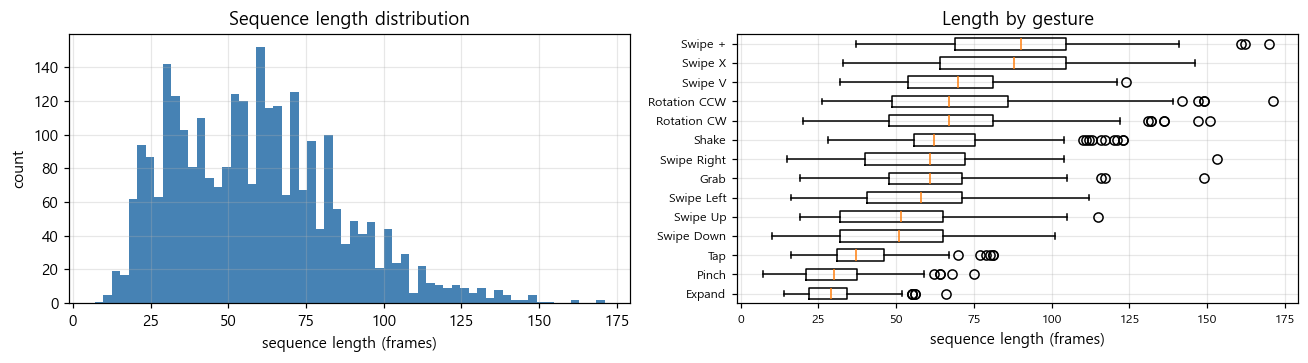

In [12]:
lengths = np.array([len(s) for s in sequences])

print(f"프레임 수: 최소 {lengths.min()}  중앙값 {np.median(lengths):.0f}  "
      f"평균 {lengths.mean():.1f}  최대 {lengths.max()}")
print(f"초 단위(30fps): 최소 {lengths.min()/C.FPS:.2f}s  중앙값 {np.median(lengths)/C.FPS:.2f}s  "
      f"최대 {lengths.max()/C.FPS:.2f}s")
for p in (1, 5, 10, 25, 50, 75, 90, 95):
    print(f"   p{p:<2} = {np.percentile(lengths, p):5.0f} frames")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(lengths, bins=60, color="steelblue")
axes[0].set_xlabel("sequence length (frames)")
axes[0].set_ylabel("count")
axes[0].set_title("Sequence length distribution")

order = sorted(C.GESTURE_NAMES, key=lambda g: np.median([len(s) for r, s in zip(records, sequences) if r.label14 == g]))
axes[1].boxplot([[len(s) for r, s in zip(records, sequences) if r.label14 == g] for g in order],
                tick_labels=[C.GESTURE_NAMES[g] for g in order], vert=False, widths=0.6)
axes[1].set_xlabel("sequence length (frames)")
axes[1].set_title("Length by gesture")
axes[1].tick_params(labelsize=8)
fig.tight_layout()
plt.show()

### 발견

* 길이 편차가 매우 크다: **최소 7프레임(0.23초) ~ 최대 171프레임(5.7초)**, 중앙값 57프레임(1.9초).
* **길이가 제스처와 강하게 상관된다.** 오른쪽 박스플롯에서 보이듯
  `Shake`는 길고 `Expand`·`Pinch`는 짧다.
* **결론(중요):** 길이 기준으로 시퀀스를 걸러내면 **제스처 분포가 함께 왜곡된다.**
  2.2절에서 확인한 완벽한 균형이 길이 필터 한 번에 깨진다는 뜻이다.
  이 사실은 4.3절에서 정량적으로 확인한다.

---
# Tier 3 — 신호 (Signal)

> 손의 움직임은 실제로 어떻게 생겼는가?

## 3.1 관절 구조 검증

**이 확인이 바꾸는 결정:** 어느 관절을 원점(root)으로 삼을 것인가, 뼈 기반 특징이 유효한가.

문서에는 "손목, 손바닥, 그다음 손가락 5개 × 4관절"이라고 되어 있다.
그러나 문서를 믿는 대신 **기하학적으로 복원**할 수 있다.
관절이 체인 순서라면 **연속된 인덱스** 사이 거리는 손가락 내부에서 작고 체인 경계에서 튀어야 한다.

In [13]:
seg = np.mean([
    np.median(np.linalg.norm(np.diff(s, axis=1), axis=2), axis=0) for s in sequences
], axis=0) * C.MM_PER_M

print("연속된 관절 인덱스 사이의 중앙 거리 (전체 2800개 평균, mm)")
for i, v in enumerate(seg):
    print(f"   J{i:<2} -> J{i+1:<2} {v:6.1f}{'   <-- 체인 경계' if v > 70 else ''}")

연속된 관절 인덱스 사이의 중앙 거리 (전체 2800개 평균, mm)
   J0  -> J1    52.9
   J1  -> J2    40.3
   J2  -> J3    39.8
   J3  -> J4    39.8
   J4  -> J5    24.8
   J5  -> J6    52.5
   J6  -> J7    44.3
   J7  -> J8    21.1
   J8  -> J9    19.1
   J9  -> J10   85.0   <-- 체인 경계
   J10 -> J11   48.3
   J11 -> J12   28.9
   J12 -> J13   21.1
   J13 -> J14   83.9   <-- 체인 경계
   J14 -> J15   45.2
   J15 -> J16   24.5
   J16 -> J17   22.3
   J17 -> J18   86.7   <-- 체인 경계
   J18 -> J19   39.8
   J19 -> J20   19.2
   J20 -> J21   16.5


In [14]:
# root 후보 비교: 어느 관절이 더 중심에 있는가
d0 = np.mean([np.linalg.norm(s[0] - s[0, 0], axis=1) for s in sequences], axis=0) * C.MM_PER_M
d1 = np.mean([np.linalg.norm(s[0] - s[0, 1], axis=1) for s in sequences], axis=0) * C.MM_PER_M

print(f"{'':22}{'J0(손목) 기준':>16}{'J1(손바닥) 기준':>18}")
print(f"{'다른 관절까지 최대':22}{d0.max():>13.1f} mm{d1.max():>15.1f} mm")
print(f"{'다른 관절까지 평균':22}{d0.mean():>13.1f} mm{d1.mean():>15.1f} mm")

                             J0(손목) 기준        J1(손바닥) 기준
다른 관절까지 최대                    172.2 mm          124.0 mm
다른 관절까지 평균                    111.4 mm           73.9 mm


### 발견

* **J9→J10, J13→J14, J17→J18**에서 약 85~89 mm의 뚜렷한 단절이 나타난다.
  체인 내부는 17~50 mm 수준이므로 경계가 명확하다.
* 따라서 구조는 **손목(J0), 손바닥(J1), 그리고 4관절 체인 5개**
  `[2,3,4,5] [6,7,8,9] [10,11,12,13] [14,15,16,17] [18,19,20,21]`로 확인된다.
  체인 안에서 마디 길이가 끝으로 갈수록 짧아지는 것도 실제 손가락뼈와 일치한다.
* **root 선택:** 모든 관절이 손목(J0)보다 **손바닥(J1)에 더 가깝다.**
  최대 거리 **172.2 mm(J0) vs 124.0 mm(J1)**, 평균 거리 **111.4 mm vs 73.9 mm**로
  손바닥 기준이 뚜렷하게 더 조밀하다. 즉 손바닥이 기하학적 중심이다.
* **결론:** 제안서의 "손목 기준"을 문자 그대로 따르기보다 **손바닥(J1)을 원점으로 쓰는 편이
  수치적으로 안정적**이다. 로컬 좌표가 더 작게 유지되기 때문이다.

## 3.2 움직임 속도 분포

**이 확인이 바꾸는 결정:** "정상적인 움직임"의 범위는 어디까지인가 → 이상치 기준을 정하는 근거.

In [15]:
speeds = np.concatenate([
    np.linalg.norm(np.diff(s[:, 1, :], axis=0), axis=1) * C.MM_PER_M for s in sequences
])

print(f"손바닥 기준 프레임당 이동 거리 (총 {len(speeds):,}개 전이, 30fps)")
for p in (5, 25, 50, 75, 90, 95, 99, 99.9):
    v = np.percentile(speeds, p)
    print(f"   p{p:<4} = {v:7.2f} mm/frame  ({v*C.FPS/10:7.1f} cm/s)")
print(f"   최대   = {speeds.max():7.2f} mm/frame  ({speeds.max()*C.FPS/1000:.1f} m/s)")
print(f"\n거의 정지한 프레임 (<1 mm/frame): {100*(speeds<1).mean():.1f}%")

손바닥 기준 프레임당 이동 거리 (총 162,169개 전이, 30fps)
   p5    =    0.47 mm/frame  (    1.4 cm/s)
   p25   =    1.70 mm/frame  (    5.1 cm/s)
   p50   =    5.71 mm/frame  (   17.1 cm/s)
   p75   =   13.28 mm/frame  (   39.8 cm/s)
   p90   =   21.19 mm/frame  (   63.6 cm/s)
   p95   =   26.90 mm/frame  (   80.7 cm/s)
   p99   =   45.23 mm/frame  (  135.7 cm/s)
   p99.9 =   94.88 mm/frame  (  284.6 cm/s)
   최대   =  323.68 mm/frame  (9.7 m/s)

거의 정지한 프레임 (<1 mm/frame): 15.9%


### 발견

* 중앙값 **5.71 mm/frame (약 17 cm/s)**, p99가 **45.2 mm/frame (약 1.36 m/s)**.
  사람 손 움직임으로 자연스러운 범위다.
* 그러나 **최댓값이 323.7 mm/frame ≈ 9.7 m/s**로, 사람 손이 낼 수 있는 속도가 아니다.
* 전체 프레임의 **15.9%**는 거의 정지 상태(<1 mm/frame)다.
* **결론:** p99(45.2)와 최댓값(323.7) 사이의 **7배 간극**은 분포가 두 종류임을 뜻한다 —
  실제 움직임과 **트래킹 실패**. p99.9조차 94.9에 불과하다는 점이 이를 뒷받침한다.
  다음 절에서 이를 분리한다.

## 3.3 이상치(트래킹 스파이크)

**이 확인이 바꾸는 결정:** GT를 정제해야 하는가, 임계값은 얼마로 둘 것인가.

제곱 오차 기반 지표는 이런 이상치에 지배당한다. 방치하면 평가가 "예측 품질"이 아니라
"오염된 GT"를 재게 된다.

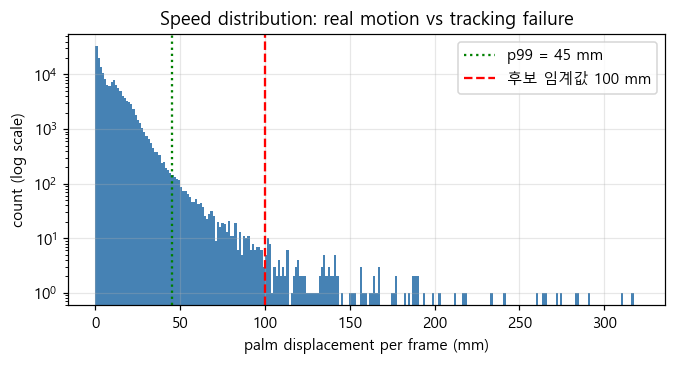

임계값  60 mm/frame -> 해당 시퀀스  424개 (15.1%), 전이  665개 (0.410%)
임계값  80 mm/frame -> 해당 시퀀스  200개 ( 7.1%), 전이  275개 (0.170%)
임계값 100 mm/frame -> 해당 시퀀스  109개 ( 3.9%), 전이  142개 (0.088%)
임계값 150 mm/frame -> 해당 시퀀스   40개 ( 1.4%), 전이   47개 (0.029%)


In [16]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(speeds, bins=250, range=(0, 320), color="steelblue")
ax.axvline(np.percentile(speeds, 99), color="green", ls=":", label=f"p99 = {np.percentile(speeds,99):.0f} mm")
ax.axvline(100, color="red", ls="--", label="후보 임계값 100 mm")
ax.set_yscale("log")
ax.set_xlabel("palm displacement per frame (mm)")
ax.set_ylabel("count (log scale)")
ax.set_title("Speed distribution: real motion vs tracking failure")
ax.legend()
plt.show()

for thr in (60, 80, 100, 150):
    n_seq = sum(1 for s in sequences
                if (np.linalg.norm(np.diff(s[:, 1, :], axis=0), axis=1) * C.MM_PER_M > thr).any())
    n_fr = int((speeds > thr).sum())
    print(f"임계값 {thr:>3} mm/frame -> 해당 시퀀스 {n_seq:>4}개 ({100*n_seq/len(sequences):>4.1f}%), "
          f"전이 {n_fr:>4}개 ({100*n_fr/len(speeds):.3f}%)")

### 발견

* 로그 스케일 히스토그램에서 약 50 mm 이후 분포가 **꺾이며 긴 꼬리**가 이어진다.
  이 꼬리가 트래킹 실패 구간이다.
* 임계값을 100 mm/frame으로 두면 전체 전이의 **0.088%(142개)**,
  시퀀스의 **3.9%(109개)**가 걸린다.
  실제 움직임의 p99(45.2 mm)보다 두 배 이상 높으므로 **빠른 제스처는 살아남는다.**
* 임계값을 60으로 낮추면 시퀀스의 15.1%가 걸려 과도하고,
  150으로 올리면 1.4%만 걸려 명백한 실패를 놓친다. **100이 적절한 절충**이다.
* **결론:** 임계값 **100 mm/frame**이 합리적이다.
  스파이크가 있는 시퀀스는 **학습 데이터에는 남기고**(실제 트래커 노이즈를 반영),
  **평가 구간에서는 배제**하는 것이 타당하다.
  또한 스파이크로 판정된 전이는 그것이 잇는 **두 프레임 모두** 무효로 봐야 한다 —
  둘 중 어느 쪽이 잘못된 측정인지 알 수 없기 때문이다.

## 3.4 노이즈 바닥 (GT는 얼마나 깨끗한가)

**이 확인이 바꾸는 결정:** 정규화를 프레임마다 할 것인가 여러 프레임을 모아서 할 것인가.
나아가 **어떤 모델도 넘을 수 없는 정확도 상한**이 어디인가.

실제 뼈는 강체이므로 길이가 변하지 않아야 한다. 그런데 추정된 스켈레톤에서 뼈 길이가 흔들린다면,
그 흔들림은 전부 **추정 노이즈**다. 이를 우리가 제거하려는 **신호**(피험자 간 손 크기 차이)와 비교한다.

In [17]:
bone_mean, bone_cv = [], []
for s in sequences:
    b = np.linalg.norm(s[:, 1, :] - s[:, 0, :], axis=1) * C.MM_PER_M
    bone_mean.append(b.mean())
    bone_cv.append(b.std() / b.mean())
bone_mean, bone_cv = np.array(bone_mean), np.array(bone_cv)

between = bone_mean.std() / bone_mean.mean()
within = bone_cv.mean()

print(f"손목->손바닥 뼈 길이")
print(f"   평균 {bone_mean.mean():.1f} mm, 범위 {bone_mean.min():.1f} ~ {bone_mean.max():.1f} mm")
print(f"   피험자 간 편차 (신호)   {100*between:.1f}%")
print(f"   시퀀스 내부 CV (노이즈) {100*within:.1f}%")
print(f"\n노이즈/신호 비 = {within/between:.2f}")
print(f"N={C.INPUT_LEN} 프레임 평균 시 노이즈: {100*within/np.sqrt(C.INPUT_LEN):.1f}%")

손목->손바닥 뼈 길이
   평균 52.9 mm, 범위 34.1 ~ 76.0 mm
   피험자 간 편차 (신호)   13.5%
   시퀀스 내부 CV (노이즈) 13.6%

노이즈/신호 비 = 1.01
N=20 프레임 평균 시 노이즈: 3.0%


### 발견

* 손목→손바닥 뼈의 **시퀀스 내부 변동(노이즈) 13.6%**,
  **피험자 간 편차(신호) 13.5%**로 비율이 **1.01** — 거의 정확히 같다.
* **결론(중요):** 한 프레임에서 잰 뼈 길이는 **신호만큼 노이즈가 크다.**
  따라서 프레임별(per-frame) 스케일 정규화를 하면 제거하려던 만큼의 오차를 다시 집어넣게 된다.
  N=20 프레임에 대해 평균(또는 중앙값)을 내면 √N만큼 줄어 약 3%가 되어
  비로소 신호보다 충분히 작아진다.
  → **스케일은 반드시 여러 프레임을 모아서 계산해야 한다.**
* 부수적으로, 이 14%가 **GT 자체의 노이즈 바닥**이다. 어떤 모델도 이보다 정확할 수 없다.

## 3.5 시퀀스 내 움직임 위치

**이 확인이 바꾸는 결정:** 가림 구간을 균일 무작위로 배치해도 되는가,
아니면 움직이는 구간으로 편향시켜야 하는가.

시퀀스 앞뒤에 손이 멈춰 있는 여백이 많다면, 무작위 마스크가 자주 "죽은 구간"에 떨어져
모든 방법이 좋은 점수를 받고 오차 곡선이 평평해진다. **가정하지 말고 측정한다.**

시퀀스 내 위치별 평균 손바닥 속도 (mm/frame)
   앞 20%     8.71
   중간 60%  10.02
   뒤 20%     6.01


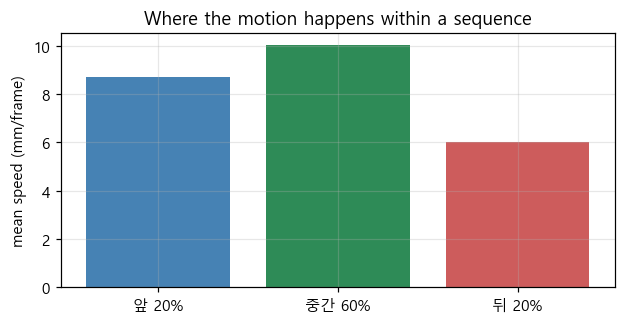

In [18]:
lead, mid, tail = [], [], []
for s in sequences:
    v = np.linalg.norm(np.diff(s[:, 1, :], axis=0), axis=1) * C.MM_PER_M
    if len(v) < 15:
        continue
    k = max(1, len(v) // 5)
    lead.append(v[:k].mean()); mid.append(v[k:len(v)-k].mean()); tail.append(v[len(v)-k:].mean())

print(f"시퀀스 내 위치별 평균 손바닥 속도 (mm/frame)")
print(f"   앞 20%    {np.mean(lead):5.2f}")
print(f"   중간 60%  {np.mean(mid):5.2f}")
print(f"   뒤 20%    {np.mean(tail):5.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(["앞 20%", "중간 60%", "뒤 20%"], [np.mean(lead), np.mean(mid), np.mean(tail)],
       color=["steelblue", "seagreen", "indianred"])
ax.set_ylabel("mean speed (mm/frame)")
ax.set_title("Where the motion happens within a sequence")
plt.show()

### 발견

* 앞 20% **8.71**, 중간 60% **10.02**, 뒤 20% **6.01** mm/frame.
* 앞부분은 중간의 **87% 수준**으로 다소 느리지만, "정지"라고 부를 만한 수준이 전혀 아니다.
  오히려 **뒤 20%(중간의 60%)가 더 느리다** — 제스처를 마치고 손을 멈추는 구간이다.
* **결론:** SHREC 시퀀스는 **이미 잘 잘려 있어** 앞부분에 긴 대기 구간이 없다.
  따라서 **균일 무작위 마스킹으로 충분**하며, 움직임 구간으로 편향시키는 추가 로직은 불필요하다.
  (직관적으로는 "앞뒤에 여백이 클 것"이라 예상하기 쉬우므로, 측정으로 확인한 의미가 있다.
  다만 뒷부분이 느리다는 점은 기억해 둘 만하다.)

---
# Tier 4 — 실험 타당성 (Feasibility)

> 일반적인 EDA는 여기서 끝나지만, 이 프로젝트에 필요한 확인은 지금부터다.

## 4.1 가림 실험이 가능한 시퀀스 수

**이 확인이 바꾸는 결정:** 어떤 L까지 실험할 수 있는가, 평가 집합을 어떻게 정할 것인가.

관측 N프레임 + 가림 L프레임이 한 시퀀스 안에 들어가야 하므로 최소 `N + L` 프레임이 필요하다.

In [19]:
N = C.INPUT_LEN
print(f"입력 길이 N = {N} 프레임 고정\n")
print(f"{'L':>4} {'초':>6} {'필요':>6} {'train':>7} {'test':>7} {'전체':>7}")
for L in C.GAP_LENGTHS:
    need = N + L
    tr = sum(1 for r in train if r.n_frames >= need)
    te = sum(1 for r in test if r.n_frames >= need)
    print(f"{L:>4} {L/C.FPS:>6.2f} {need:>6} {tr:>7} {te:>7} {tr+te:>7}")

common = sum(1 for r in test if r.n_frames >= N + max(C.GAP_LENGTHS))
print(f"\n모든 L을 공통으로 만족하는 test 시퀀스: {common}개")
print(f"L=5 만 만족: {sum(1 for r in test if r.n_frames >= N+5)}개 -> 차이 "
      f"{sum(1 for r in test if r.n_frames >= N+5) - common}개")

입력 길이 N = 20 프레임 고정

   L      초     필요   train    test      전체
   5   0.17     25    1810     768    2578
  10   0.33     30    1694     717    2411
  20   0.67     40    1385     618    2003
  30   1.00     50    1165     531    1696

모든 L을 공통으로 만족하는 test 시퀀스: 531개
L=5 만 만족: 768개 -> 차이 237개


### 발견

* L이 커질수록 사용 가능한 시퀀스가 급격히 줄어든다. test 기준 **768 → 531개** (약 31% 감소).
* **결론(가장 중요한 설계 판단):** L마다 "그때그때 길이가 되는 시퀀스"를 쓰면
  네 개의 오차 곡선이 **서로 다른 표본 집단** 위에 놓인다.
  그러면 곡선이 교차하더라도 그것이 *가림이 길어져서*인지 *데이터가 바뀌어서*인지 구분할 수 없다.
  본 프로젝트의 핵심 산출물이 바로 그 **교차점**이므로 이는 치명적이다.
  → **모든 L을 동일한 시퀀스 집합(≥ 50프레임, test 531개)에서 평가해야 한다.**

## 4.2 길이 필터가 클래스 균형에 미치는 영향

**이 확인이 바꾸는 결정:** 제스처별 결과를 보고할 수 있는가, 가중치 보정이 필요한가.

2.2절에서 원본은 완벽히 균형 잡혀 있었고, 2.3절에서 길이가 제스처와 상관됨을 보았다.
그렇다면 4.1절의 길이 필터는 균형을 얼마나 깨뜨릴까?

In [20]:
thr = N + max(C.GAP_LENGTHS)
before = Counter(r.label14 for r in test)
after = Counter(r.label14 for r in test if r.n_frames >= thr)

print(f"test split, {thr}프레임 이상 필터 전후\n")
print(f"{'id':>3} {'gesture':<14} {'필터 전':>8} {'필터 후':>8} {'잔존율':>8}")
for g in sorted(before):
    rate = 100 * after[g] / before[g]
    bar = "#" * int(rate / 5)
    print(f"{g:>3} {C.GESTURE_NAMES[g]:<14} {before[g]:>8} {after[g]:>8} {rate:>7.0f}% {bar}")

vals = np.array([after[g] for g in sorted(before)])
print(f"\n필터 후 최소 {vals.min()}개 / 최대 {vals.max()}개 -> {vals.max()/vals.min():.1f}배 격차")

test split, 50프레임 이상 필터 전후

 id gesture            필터 전     필터 후      잔존율
  1 Grab                 58       47      81% ################
  2 Tap                  61       16      26% #####
  3 Expand               55        5       9% #
  4 Pinch                51        9      18% ###
  5 Rotation CW          55       46      84% ################
  6 Rotation CCW         58       44      76% ###############
  7 Swipe Right          62       45      73% ##############
  8 Swipe Left           54       37      69% #############
  9 Swipe Up             68       35      51% ##########
 10 Swipe Down           61       32      52% ##########
 11 Swipe X              69       50      72% ##############
 12 Swipe +              57       49      86% #################
 13 Swipe V              58       50      86% #################
 14 Shake                73       66      90% ##################

필터 후 최소 5개 / 최대 66개 -> 13.2배 격차


### 발견

* 필터 후 **최소 5개(Expand, 잔존율 9%) ~ 최대 66개(Shake, 잔존율 90%)**로
  **13.2배 격차**가 생긴다.
  `Shake`·`Swipe +`·`Swipe V`처럼 긴 제스처는 대부분 살아남고,
  `Expand`(9%)·`Pinch`(18%)·`Tap`(26%)처럼 짧은 제스처는 대부분 탈락한다.
* **Expand가 5개 남는다는 것은 사실상 통계를 낼 수 없다는 뜻**이다.
* **결론:** 이는 4.1절의 필터가 만들어내는 **구조적 부작용**이며, 피할 수 없다
  (길이 필터를 포기하면 4.1의 더 심각한 문제가 생긴다).
  따라서 **제스처별 결과를 보고할 때는 표본 수가 적은 클래스에 신뢰구간을 반드시 표시**하거나
  가중 평균을 써야 한다.
  연구 질문 "학습 모델이 제스처별 패턴을 예측하는가"에 답할 때 특히 주의해야 한다.

## 4.3 제스처별 움직임 특성

**이 확인이 바꾸는 결정:** 물리 기반 외삽이 통할 제스처와 통하지 않을 제스처를 미리 파악한다.

궤적을 직접 그려 보면, 제스처에 따라 예측 문제의 성격이 완전히 다르다는 것이 드러난다.

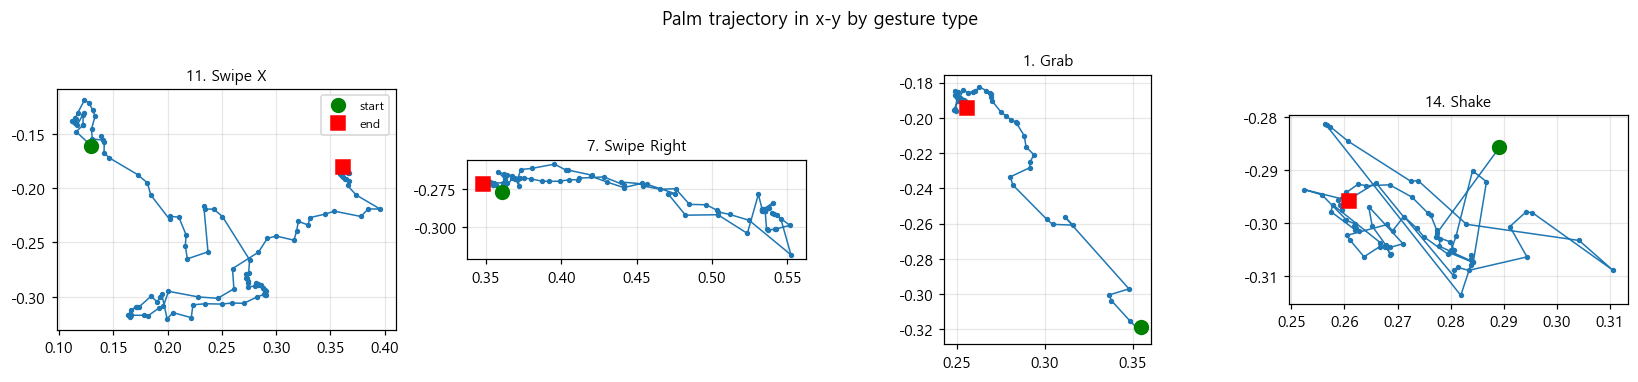

In [21]:
picks = [11, 7, 1, 14]   # Swipe X, Swipe Right, Grab, Shake
fig, axes = plt.subplots(1, len(picks), figsize=(15, 3.5))

for ax, g in zip(axes, picks):
    idx = next(i for i, r in enumerate(records) if r.label14 == g and r.n_frames >= 60)
    p = sequences[idx][:, 1, :]
    ax.plot(p[:, 0], p[:, 1], "o-", ms=2.5, lw=1)
    ax.plot(p[0, 0], p[0, 1], "go", ms=9, label="start")
    ax.plot(p[-1, 0], p[-1, 1], "rs", ms=9, label="end")
    ax.set_title(f"{g}. {C.GESTURE_NAMES[g]}", fontsize=10)
    ax.set_aspect("equal")
axes[0].legend(fontsize=8)
fig.suptitle("Palm trajectory in x-y by gesture type")
fig.tight_layout()
plt.show()

움직임의 "곧음"을 **직진성(straightness) = 순변위 / 경로길이**로 정량화한다.
1이면 완전한 직선, 0에 가까우면 제자리로 되돌아온다는 뜻이다.

**주의:** 이를 *시퀀스 전체* 기준으로 재면 오해를 부른다.
제자리로 돌아오는 제스처는 순변위가 0에 가까워져 직진성이 0이 되는데,
이는 "예측이 어렵다"가 아니라 "시작점과 끝점이 같다"는 뜻일 뿐이다.

가림 예측에 의미 있는 것은 **가림 길이만큼의 짧은 구간**에서의 직진성이다.
따라서 길이 W의 슬라이딩 윈도우로 측정한다.

In [22]:
def windowed_straightness(pos, W, stride=5):
    out = []
    for a in range(0, len(pos) - W, stride):
        w = pos[a:a + W + 1]
        path = np.linalg.norm(np.diff(w, axis=0), axis=1).sum()
        if path > 1e-9:
            out.append(np.linalg.norm(w[-1] - w[0]) / path)
    return out

by_gesture = {g: [] for g in C.GESTURE_NAMES}
for r, s in zip(records, sequences):
    by_gesture[r.label14].append(s[:, 1, :])

print("윈도우 길이별 평균 직진성 (1 = 완전 직선, 0 = 제자리 복귀)")
print(f"{'id':>3} {'gesture':<14}" + "".join(f"{'W=' + str(W):>8}" for W in C.GAP_LENGTHS))
rows = []
for g, poss in by_gesture.items():
    vals = {}
    for W in C.GAP_LENGTHS:
        acc = []
        for p in poss:
            if len(p) > W + 1:
                acc += windowed_straightness(p, W)
        vals[W] = float(np.mean(acc)) if acc else float("nan")
    rows.append((vals[max(C.GAP_LENGTHS)], g, vals))

for _, g, vals in sorted(rows, reverse=True):
    print(f"{g:>3} {C.GESTURE_NAMES[g]:<14}"
          + "".join(f"{vals[W]:>8.2f}" for W in C.GAP_LENGTHS))

overall = {W: float(np.mean([v[W] for _, _, v in rows])) for W in C.GAP_LENGTHS}
print(f"\n{'전체 평균':<18}" + "".join(f"{overall[W]:>8.2f}" for W in C.GAP_LENGTHS))

윈도우 길이별 평균 직진성 (1 = 완전 직선, 0 = 제자리 복귀)
 id gesture            W=5    W=10    W=20    W=30


  1 Grab              0.83    0.78    0.68    0.58
  9 Swipe Up          0.80    0.74    0.66    0.58
  7 Swipe Right       0.76    0.70    0.63    0.54
 13 Swipe V           0.80    0.74    0.64    0.53
  8 Swipe Left        0.76    0.69    0.61    0.51
 12 Swipe +           0.81    0.75    0.64    0.51
 11 Swipe X           0.80    0.73    0.62    0.50
 10 Swipe Down        0.77    0.69    0.58    0.46
  3 Expand            0.73    0.64    0.54    0.45
  6 Rotation CCW      0.73    0.63    0.53    0.45
  4 Pinch             0.72    0.59    0.47    0.41
  5 Rotation CW       0.69    0.58    0.46    0.38
  2 Tap               0.76    0.65    0.48    0.34
 14 Shake             0.62    0.38    0.20    0.14

전체 평균                 0.76    0.66    0.55    0.45


### 발견

* **윈도우가 길어질수록 직진성이 단조 감소**한다.
  전체 평균 기준 **W=5에서 0.76 → W=30에서 0.45**.
  즉 1초(30프레임) 동안 손은 경로 길이의 **절반도 안 되는 순변위**만 만든다.
  짧은 구간에서는 거의 직선이지만, 길어질수록 방향을 바꾸고 되돌아온다는 뜻이다.
* 제스처별 차이가 뚜렷하다. W=30 기준 **Grab 0.58 ~ Shake 0.14로 4배 격차**.
  `Shake`는 W=5에서 이미 0.62로 낮고 W=30에서 0.14까지 떨어진다 —
  이름 그대로 좁은 영역에서 흔드는 동작이기 때문이다.
* **결론(예측):** 직진성은 등속 외삽이 통할지를 그대로 예고한다.
  직진성이 s라면 직선 외삽은 실제 도달점을 대략 `1/s` 배만큼 **초과(overshoot)**하게 된다.
  전체 평균 0.45라면 L=30에서 약 **2배 과도 예측**이 예상된다.
  따라서 물리 기반 외삽은 **W가 작을 때, 그리고 직진성이 높은 제스처에서만 유리**할 것이다.
  극단적으로, 직진성이 매우 낮은 구간에서는
  "마지막 위치에 그대로 멈춰 있다"는 단순한 가정이 등속 외삽보다 **더 정확할 수 있다.**
  → 물리 vs 학습의 교차점은 **가림 길이 L만의 함수가 아니라 제스처 종류에도 의존**할 수 있다.
  이는 제안서가 예상하지 못한 부분이며, 오히려 더 흥미로운 결과가 될 수 있다.

> **작성 시 주의했던 점:** 처음에는 이 지표를 시퀀스 전체로 계산했는데,
> 그러면 `Swipe X`(X자 그리기)나 `Swipe +`(+자 그리기)처럼 여러 획으로 이루어진 제스처가
> 매우 낮은 값을 받는다. 이름에 "Swipe"가 들어간다고 직선 운동이라 단정하면 안 된다.
> 지표를 정의할 때 **"그 값이 실제로 무엇을 재는지"**를 확인해야 한다는 사례다.

## 4.4 depth 이미지가 필요한가

**이 확인이 바꾸는 결정:** 22 GB의 depth PNG를 실제로 쓸 것인가.

형식 I;16, 크기 (640, 480), dtype uint16
값 범위 0 ~ 1946   (16-bit 최대는 65535)
-> 실제로 쓰는 범위는 전체의 3.0% 뿐
값이 0인 픽셀(깊이 측정 실패): 88.9%


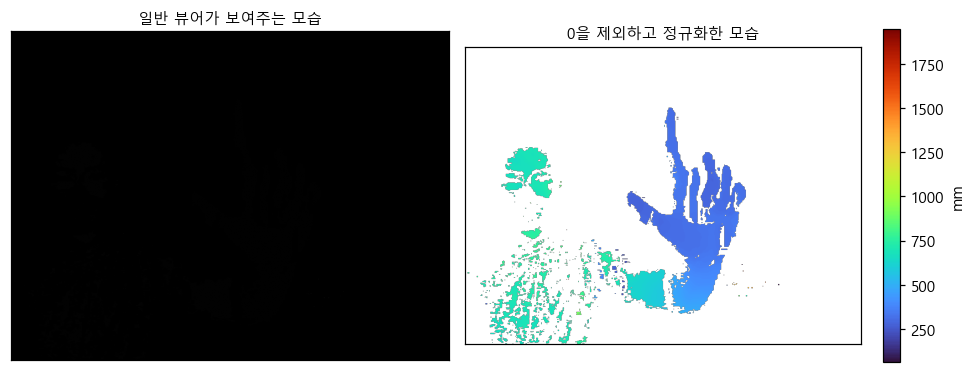

In [23]:
import matplotlib.image as mpimg
from PIL import Image

p = records[0].dir_path / "20_depth.png"
img = Image.open(p)
a = np.array(img).astype(np.float64)

print(f"형식 {img.mode}, 크기 {img.size}, dtype {np.array(img).dtype}")
print(f"값 범위 {a.min():.0f} ~ {a.max():.0f}   (16-bit 최대는 65535)")
print(f"-> 실제로 쓰는 범위는 전체의 {100*a.max()/65535:.1f}% 뿐")
print(f"값이 0인 픽셀(깊이 측정 실패): {100*(a==0).mean():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].imshow(a, cmap="gray", vmin=0, vmax=65535)
axes[0].set_title("일반 뷰어가 보여주는 모습", fontsize=10)
masked = np.ma.masked_where(a == 0, a)
im = axes[1].imshow(masked, cmap="turbo")
axes[1].set_title("0을 제외하고 정규화한 모습", fontsize=10)
plt.colorbar(im, ax=axes[1], fraction=0.046, label="mm")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

### 발견

* depth PNG는 **16-bit(0~65535) 형식이지만 실제 값은 깊이(mm)로 약 1900까지**만 쓴다.
  전체 범위의 **3% 남짓**만 사용하므로 일반 뷰어에서는 **거의 새까맣게** 보인다.
  파일이 손상된 것이 아니다. 왼쪽/오른쪽 그림은 **완전히 동일한 파일**이다.
  (손이 약 500 mm 거리에 있으므로 8-bit로 환산하면 255 중 약 2에 해당한다.)
* 픽셀의 **약 89%가 0**이며, 이는 "거리 0"이 아니라 **깊이 측정 실패(no return)**를 뜻한다.
  따라서 정규화 전에 반드시 `0`을 마스킹해야 한다.
  마스킹하지 않고 `a / a.max()`로 정규화하면 측정 실패 영역이 "가장 가까운 표면"으로
  렌더링되어 사실과 정반대가 된다.
* **주의:** `cv2.imread(path)`는 8-bit BGR로 변환하며 깊이 정보를 **조용히 파괴**한다.
  반드시 `cv2.IMREAD_UNCHANGED`를 쓰거나 PIL로 읽어야 한다.
* **결론:** 본 실험의 핵심(궤적 예측)은 `skeletons_world.txt`만으로 가능하며
  depth 이미지는 **선택 과제인 정성 오버레이 데모에만** 필요하다.
  또한 SHREC'17에는 **RGB 영상이 없으므로** 데모는 이런 흑백/컬러맵 depth 위에 그려진다.

---
# 5. 종합 정리

## 발견 → 결정 대응표

| # | 발견 | 값 | 이후 결정 |
|---|---|---|---|
| 1.1 | 시퀀스 수 / 설계 | 2800, 피험자 28명, **완전교차 아님** | 압축 해제 완전. 균형은 클래스 축에서만 성립 |
| 1.2 | 열 개수 | 전부 66열 (22×3) | 예외 없이 일괄 reshape 가능 |
| 1.3 | 프레임 수 일치 | 불일치 0건, PNG 164,969장 | `frame_k` ↔ `k_depth.png` 대응 보장 |
| 1.4 | 결측 | NaN 0건 | 보간 불필요, 인위적 가림 생성 전제 성립 |
| 1.5 | 단위 | 미터 (손 ≈ 132 mm, z ≈ 490 mm) | 오차는 ×1000 하여 mm로 보고 |
| 2.1 | 공식 분할 | 피험자 20 vs 8, 중복 **0명** | **공식 분할 그대로 사용**, 무작위 셔플 금지 |
| 2.2 | 클래스 균형 | 전체는 각 200개, split 내부는 편차 있음 | 원본 단계에서는 보정 불필요 |
| 2.3 | 시퀀스 길이 | 7 ~ 171, 중앙값 57 | 길이가 제스처와 상관 → 필터 시 균형 붕괴 |
| 3.1 | 관절 구조 | J9/J13/J17에서 84~87 mm 경계 | 손목+손바닥+5체인 확인, **root = 손바닥(J1)** |
| 3.2 | 속도 | 중앙값 5.71, p99 45.2 mm/frame | 정상 움직임 범위 확정 |
| 3.3 | 이상치 | 최대 **323.7** mm/frame (9.7 m/s) | **임계값 100 mm/frame**, 학습엔 유지·평가엔 배제 |
| 3.4 | 노이즈 바닥 | 노이즈 **13.6%** ≈ 신호 **13.5%** | **스케일은 여러 프레임을 모아 계산** |
| 3.5 | 움직임 위치 | 앞 8.71 / 중간 10.02 / 뒤 6.01 | 대기 구간 없음 → **균일 무작위 마스킹으로 충분** |
| 4.1 | L별 사용 가능 수 | test 768 → **531** | **모든 L을 동일 집합(≥50프레임)에서 평가** |
| 4.2 | 필터 후 균형 | **5개(Expand) ~ 66개(Shake), 13.2배** | 제스처별 보고 시 **신뢰구간 필수** |
| 4.3 | 윈도우 직진성 | 평균 **0.76(W=5) → 0.45(W=30)**, Shake 0.14 | L=30에서 약 2배 과도 예측 예상. 교차점이 **제스처 종류에도 의존** |
| 4.4 | depth 이미지 | 16-bit, **89%가 0**, 범위의 3%만 사용 | 핵심 실험엔 불필요, 데모용으로만 |

## 다음 단계(전처리)로 넘어갈 때의 핵심 판단 3가지

1. **좌표 표현** — 제안서의 "손목 기준 상대 좌표"를 그대로 적용하면 매 프레임 root가 원점이 되어
   **전역 이동 성분이 사라진다.** 그런데 전역 이동이야말로 칼만·등속 모델이 잘 예측하는 대상이다.
   → 전역(root 위치)과 지역(관절 형상)을 **분리해서 보존**하는 표현이 필요하다.
2. **평가 집합 고정** — 4.1의 결론에 따라 모든 L이 **같은 시퀀스, 같은 관측 윈도우**를 쓰도록
   가림 위치를 미리 고정해야 한다. 그래야 L만이 유일한 변수가 된다.
3. **스케일 정규화 방식** — 3.4에 따라 프레임별이 아니라 **관측 윈도우 전체의 중앙값**으로 계산하고,
   가려진 구간의 정보가 새어 들어가지 않도록 **관측된 프레임만** 사용해야 한다.